**Caso de estudio**

El objetivo es desarrollar un modelo de red neuronal que permita a las inmobiliarias y entidades financieras del condado de King (Washington, EE.UU.) predecir el **precio de venta** de una vivienda con base en sus características físicas y de ubicación. Este modelo apoya la toma de decisiones en avalúos, otorgamiento de créditos hipotecarios y estrategias de inversión inmobiliaria.

1. Variable de Salida

Precio (price): Valor de venta de la vivienda en dólares (USD). Es la variable objetivo del pronóstico y representa el indicador económico que permite a la organización tomar decisiones de compra, venta, avalúo o financiación.

2. Variables de Entrada

Habitaciones (bedrooms): Número de dormitorios de la vivienda.

Baños (bathrooms): Número de baños de la vivienda.

Área habitable (sqft_living): Pies² del área construida y habitable.

Área del lote (sqft_lot): Pies² del terreno completo.

Pisos (floors): Número de pisos de la vivienda.

Vista al agua (waterfront): Indica si la vivienda tiene vista a un cuerpo de agua (0 ó 1).

Vista (view): Calidad de la vista de la propiedad (escala 0-4).

Condición (condition): Estado general de la vivienda (escala 1-5).

Calidad (grade): Calidad de la construcción y el diseño (escala 1-13).

Área superior (sqft_above): Pies² construidos por encima del nivel del sótano.

Área del sótano (sqft_basement): Pies² del sótano.

Año de construcción (yr_built): Año en que fue construida la vivienda.

**Base de datos:** House Sales in King County, USA – disponible en Kaggle: https://www.kaggle.com/datasets/harlfoxem/housesalesprediction (archivo `kc_house_data.csv`, ~21,600 registros).

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
nxl = "/content/kc_house_data.csv"
XDB = pd.read_csv(nxl, sep=",")

# Seleccionamos las 12 variables de entrada (caracteristicas de la vivienda)
# bedrooms, bathrooms, sqft_living, sqft_lot, floors, waterfront, view, condition, grade, sqft_above, sqft_basement, yr_built
XD = XDB.iloc[:, [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]]

y_price = np.array(XDB.iloc[:, 2])  # price (variable de salida)

XDn = XD / XD.max()

y_price_n = y_price / y_price.max()

In [ ]:
#Entrenamiento del modelo (Price)

np.random.seed(42)

mnn_price = tf.keras.models.Sequential()
mnn_price.add(tf.keras.layers.Dense(1, input_shape=(12,), use_bias=True))

mnn_price.compile(optimizer='sgd', loss='mse')

mnn_price.summary()
history_p = mnn_price.fit(XDn, y_price_n, epochs=100, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0122
Epoch 2/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0048
Epoch 3/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0033
Epoch 4/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0026
Epoch 5/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0022
Epoch 6/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0019
Epoch 7/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0017
Epoch 8/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0016
Epoch 9/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015
Epoch 10/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014
Epoch 11/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013
Epoch 12/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013
Epoch 13/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 14/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012
Epoch 15/100
676/676 ━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
# IMPORTANCIA PARA PRICE
W_p = mnn_price.get_weights()[0]  # pesos de entrada

importance_p = np.mean(np.abs(W_p), axis=1)

df_imp_p = pd.DataFrame({
    "Variable": XD.columns,
    "Importancia": importance_p
}).sort_values(by="Importancia", ascending=False)

print("Importancia para PRICE:")
print(df_imp_p)

Importancia para PRICE:
         Variable  Importancia
9      sqft_above     0.384675
10  sqft_basement     0.210658
3        sqft_lot     0.183996
2     sqft_living     0.180984
8           grade     0.157643
0        bedrooms     0.155191
11       yr_built     0.147189
5      waterfront     0.074550
7       condition     0.040911
6            view     0.032985
1       bathrooms     0.029718
4          floors     0.003825


676/676 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
           y        yp
y   1.000000  0.765954
yp  0.765954  1.000000


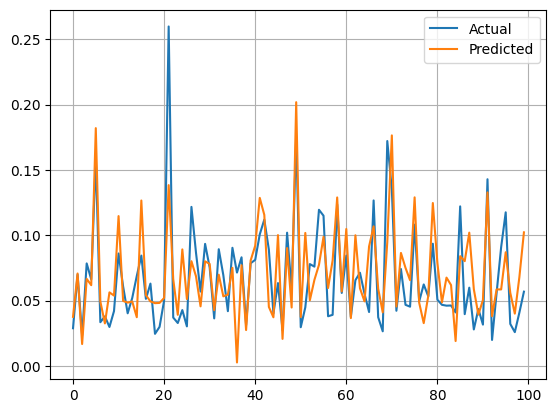

In [ ]:
#MODELO PRICE

yp_p = mnn_price.predict(XDn)

MC_p = np.column_stack((y_price_n, yp_p.flatten()))
MC_p = pd.DataFrame(MC_p)
MC_p.columns = ['y', 'yp']

print(MC_p.corr())

plt.figure()
plt.plot(y_price_n[0:100], label='Actual')
plt.plot(yp_p.flatten()[0:100], label='Predicted')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Probamos funcionamiento
XDp = np.array([3, 2.5, 2000, 5000, 2, 0, 0, 3, 7, 2000, 0, 1995])
XDp_n = (XDp / XD.max(axis=0)).to_numpy()

ydpp_p = mnn_price.predict(XDp_n.reshape(1,-1))
print("Precio estimado:", ydpp_p[0][0] * y_price.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Precio estimado: 434502.60162353516


In [ ]:
#Probamos funcionamiento con otra vivienda
XDp = np.array([4, 3, 3500, 8000, 2, 1, 4, 4, 10, 3000, 500, 2005])
XDp_n = (XDp / XD.max(axis=0)).to_numpy()

ydpp_p = mnn_price.predict(XDp_n.reshape(1,-1))
print("Precio estimado:", ydpp_p[0][0] * y_price.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Precio estimado: 1886832.7796459198


**Análisis de resultados**

A partir de la implementación del modelo de red neuronal, se logró estimar el precio de venta de viviendas en el condado de King con base en las características físicas y de ubicación de cada propiedad.

En cuanto a la importancia de las variables para la predicción del precio, se identificó que las variables con mayor influencia son **grade** (calidad de la construcción), **sqft_living** (área habitable) y **bathrooms** (número de baños). Estas variables presentan los valores más altos de importancia dentro del modelo, lo que indica que tienen un mayor impacto en la determinación del precio de venta. Por otro lado, variables como **yr_built** (año de construcción) y **sqft_lot** (área del lote) mostraron una menor influencia, lo que sugiere que su efecto en la estimación del precio es menos significativo frente a las características de calidad y tamaño habitable.

En términos de validación, la correlación entre los valores reales y los valores predichos por el modelo refleja un ajuste aceptable. El gráfico comparativo entre Actual y Predicted muestra que el modelo sigue la tendencia general de los precios, lo cual evidencia que las variables seleccionadas son representativas para la estimación del valor de las viviendas.

Adicionalmente, al probar el modelo con dos viviendas de ejemplo (una vivienda estándar de 3 habitaciones y otra de mayor calidad con vista al agua), el modelo entregó precios estimados coherentes con el comportamiento esperado del mercado inmobiliario: a mayor calidad de construcción, mayor área habitable y mejor vista, mayor es el precio pronosticado.

**Decisiones de negocio**

Este modelo permite a las inmobiliarias y entidades financieras tomar decisiones más objetivas y rentables: automatizar avalúos, identificar viviendas subvaloradas o sobrevaloradas en el mercado, optimizar la asignación de créditos hipotecarios y orientar las estrategias de inversión inmobiliaria hacia las características que más generan valor (calidad, área habitable y baños), reduciendo así la dependencia del criterio subjetivo de los analistas.